# WiDS 2026 — KM Zone Ensemble (v6)

**Why this notebook:** Notebook 05's pseudo-observations + hard distance rules dropped the leaderboard score to 0.96138 — the XGBoost on pseudo-obs overfit, and the hard caps/floors were too rigid.  
Notebook 04's D_with_AFT (0.96995) is our current best.  

**This notebook's one idea:** Use the Kaplan-Meier survival curve **directly** as a prediction model, stratified by distance zone. The KM estimator has **zero learnable parameters** — it cannot overfit. For each distance zone, it reports the empirical hit probability from training. This is then blended with the D_with_AFT survival ensemble.

**Key EDA fact:** ALL 69 training hits have dist_min_ci_0_5h < 5000m. ALL 152 censored have dist ≥ 5000m. The KM-zone model exploits this perfectly.

**Blend logic:** `final_probs = α × KM_zone_probs + (1−α) × D_with_AFT_probs`  
α is chosen by CV over [0.0, 0.1, ..., 1.0].

## 0. Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter, WeibullAFTFitter, KaplanMeierFitter
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from scipy.special import expit, logit

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.5f}'.format)

SEED          = 42
DATA_DIR      = 'Data/'
HORIZONS      = [12, 24, 48, 72]
BRIER_WEIGHTS = {24: 0.3, 48: 0.4, 72: 0.3}

In [3]:
# ──────────────────────────────────────────────────────────────────────────
#  MAIN CONFIG  ← all tunable decisions live here
# ──────────────────────────────────────────────────────────────────────────

# Distance zone boundary for the KM-zone model (metres)
# EDA: ALL training hits have dist < 5000m → use this as the separator
ZONE_BOUNDARY_M = 5000

# Blend scan: α = KM-zone weight, (1−α) = survival ensemble weight
# 0.0 = pure survival ensemble, 1.0 = pure KM-zone
KM_WEIGHT_SCAN = np.round(np.arange(0.0, 1.05, 0.10), 2)

# Enable/disable Platt calibration (sigmoid with 2 parameters per horizon)
# Much lighter than isotonic — set True to test calibration on top of blend
USE_PLATT = True

# Survival ensemble weights — these are the tuned values from nb04 D_with_AFT
SURVIVAL_WEIGHTS = {'GBT': 0.45, 'RSF': 0.30, 'CoxPH': 0.15, 'WeibullAFT': 0.10}

# Tuned params from nb04 (hardcoded to skip re-tuning)
TUNED_PARAMS = {
    'GBT': {
        'n_estimators': 362, 'learning_rate': 0.08535071943827773,
        'max_depth': 3, 'subsample': 0.9188840261236977,
        'min_samples_leaf': 24, 'max_features': 0.5, 'random_state': SEED,
    },
    'RSF': {
        'n_estimators': 311, 'min_samples_leaf': 17,
        'max_features': 0.5, 'n_jobs': -1, 'random_state': SEED,
    },
    'CoxPH':      {'penalizer': 0.0528, 'l1_ratio': 0.00395},
    'WeibullAFT': {'penalizer': 0.0528, 'l1_ratio': 0.11388},
}

N_CV_FOLDS = 5
print('Config loaded.')

Config loaded.


## 1. Data & Feature Engineering

In [4]:
train_raw = pd.read_csv(DATA_DIR + 'train.csv')
test_raw  = pd.read_csv(DATA_DIR + 'test.csv')

# Same redundant/noise drops as nb04
DROP_REDUNDANT = [
    'relative_growth_0_5h', 'area_growth_rate_ha_per_h',
    'centroid_displacement_m', 'centroid_speed_m_per_h',
    'closing_speed_m_per_h', 'projected_advance_m',
    'dist_slope_ci_0_5h', 'closing_speed_abs_m_per_h',
]
DROP_NOISE = [
    'event_start_hour', 'event_start_dayofweek', 'event_start_month',
    'along_track_speed', 'cross_track_component', 'dist_accel_m_per_h2',
]

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['log1p_dist_min']    = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_under_5km']    = (df['dist_min_ci_0_5h'] < 5000).astype(int)
    df['is_growing']        = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['speed_x_alignment'] = df['radial_growth_rate_m_per_h'] * df['alignment_abs']
    drop = [c for c in DROP_REDUNDANT + DROP_NOISE if c in df.columns]
    df   = df.drop(columns=drop)
    meta = [c for c in ['event_id', 'time_to_hit_hours', 'event'] if c in df.columns]
    return df.drop(columns=meta)

# Exactly the 9 features with positive importance from nb04
SELECTED_FEATURES = [
    'dist_min_ci_0_5h', 'dist_under_5km', 'log1p_dist_min',
    'num_perimeters_0_5h', 'dt_first_last_0_5h', 'area_first_ha',
    'log1p_area_first', 'alignment_cos', 'spread_bearing_sin'
]

X_all  = build_features(train_raw)[SELECTED_FEATURES]
X_test = build_features(test_raw)[SELECTED_FEATURES]
y_event = train_raw['event'].values.astype(bool)
y_time  = train_raw['time_to_hit_hours'].values

print(f'Train: {X_all.shape}, Test: {X_test.shape}')
print(f'Events: {y_event.sum()} / {len(y_event)}')
print(f'\nDistance zones (training):')
close_mask = X_all['dist_min_ci_0_5h'] < ZONE_BOUNDARY_M
print(f'  Close (<{ZONE_BOUNDARY_M}m): {close_mask.sum()} fires, {y_event[close_mask].sum()} hits')
print(f'  Far   (≥{ZONE_BOUNDARY_M}m): {(~close_mask).sum()} fires, {y_event[~close_mask].sum()} hits')

Train: (221, 9), Test: (95, 9)
Events: 69 / 221

Distance zones (training):
  Close (<5000m): 69 fires, 69 hits
  Far   (≥5000m): 152 fires, 0 hits


## 2. Metrics & Model Wrappers

In [5]:
def brier_at_horizon(ye, yt, pred, H):
    mask  = ~((ye == 0) & (yt < H))
    y_obs = ((ye == 1) & (yt <= H)).astype(float)
    return float(np.mean((y_obs[mask] - pred[mask]) ** 2))

def weighted_brier(ye, yt, pd_):
    return sum(w * brier_at_horizon(ye, yt, pd_[H], H) for H, w in BRIER_WEIGHTS.items())

def cindex(ye, yt, risk):
    return concordance_index_censored(ye.astype(bool), yt, risk)[0]

def hybrid(ci, wb):
    return 0.3 * ci + 0.7 * (1.0 - wb)

def evaluate(ye, yt, pd_, label=''):
    ci = cindex(ye, yt, pd_[24])
    wb = weighted_brier(ye, yt, pd_)
    return {'Model': label, 'C-index': ci,
            **{f'B@{H}h': brier_at_horizon(ye, yt, pd_[H], H) for H in HORIZONS},
            'W-Brier': wb, 'Hybrid': hybrid(ci, wb)}

def enforce_monotonicity(pd_):
    mat = np.column_stack([pd_[H] for H in HORIZONS]).clip(0, 1)
    mat = np.maximum.accumulate(mat, axis=1)
    return {H: mat[:, i] for i, H in enumerate(HORIZONS)}

def blend_probs(probs_a, probs_b, alpha):
    """alpha * probs_a + (1-alpha) * probs_b, then enforce monotonicity."""
    blended = {H: alpha * probs_a[H] + (1 - alpha) * probs_b[H] for H in HORIZONS}
    return enforce_monotonicity(blended)

print('Metrics defined.')

Metrics defined.


In [6]:
def _safe_eval(fn, t):
    return float(fn(float(np.clip(t, fn.x[0], fn.x[-1]))))


class CoxPHWrapper:
    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer; self.l1_ratio = l1_ratio
        self.scaler = StandardScaler(); self.model = None

    def fit(self, X, ye, yt):
        Xs = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        self.model = CoxPHFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(Xs.assign(duration=yt, event=ye.astype(int)),
                       duration_col='duration', event_col='event')
        return self

    def predict_survival_probs(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        S  = self.model.predict_survival_function(Xs, times=HORIZONS).values.T
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        return self.model.predict_partial_hazard(Xs).values


class WeibullAFTWrapper:
    def __init__(self, penalizer=0.1, l1_ratio=0.0):
        self.penalizer = penalizer; self.l1_ratio = l1_ratio
        self.scaler = StandardScaler(); self.model = None

    def fit(self, X, ye, yt):
        Xs = pd.DataFrame(self.scaler.fit_transform(X), columns=X.columns)
        self.model = WeibullAFTFitter(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model.fit(Xs.assign(duration=yt, event=ye.astype(int)),
                       duration_col='duration', event_col='event')
        return self

    def predict_survival_probs(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        S  = self.model.predict_survival_function(Xs, times=HORIZONS).values.T
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns)
        return -self.model.predict_median(Xs).values.ravel()


class RSFWrapper:
    def __init__(self, **params):
        self.model = RandomSurvivalForest(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)


class GBTWrapper:
    def __init__(self, **params):
        self.model = GradientBoostingSurvivalAnalysis(**params)

    def fit(self, X, ye, yt):
        self.model.fit(X.values, Surv.from_arrays(ye.astype(bool), yt))
        return self

    def predict_survival_probs(self, X):
        fns = self.model.predict_survival_function(X.values)
        S   = np.array([[_safe_eval(f, t) for t in HORIZONS] for f in fns])
        return {H: 1.0 - S[:, i] for i, H in enumerate(HORIZONS)}

    def get_risk_scores(self, X):
        return self.model.predict(X.values)


def build_model(name, params):
    if name == 'CoxPH':      return CoxPHWrapper(**params)
    if name == 'WeibullAFT': return WeibullAFTWrapper(**params)
    if name == 'RSF':        return RSFWrapper(**params)
    if name == 'GBT':        return GBTWrapper(**params)
    raise ValueError(f'Unknown model: {name}')

def weighted_ensemble(model_probs: dict, weights: dict) -> dict:
    total = sum(weights.values())
    combined = {H: sum(model_probs[n][H] * (weights[n] / total)
                       for n in weights) for H in HORIZONS}
    return enforce_monotonicity(combined)

print('Wrappers defined.')

Wrappers defined.


## 3. KM Zone Model

The core idea: fit a Kaplan-Meier curve per distance zone and look up the empirical hit probability directly.  
**Zero free parameters.** Cannot overfit. This is the most principled use of the distance separator.

- **Zone 0 (close, dist < 5km):** all 69 training fires hit → KM curve descends to 0 → hit probs near 1.0  
- **Zone 1 (far, dist ≥ 5km):** all 152 training fires censored → KM curve stays at 1.0 → hit probs = 0.0

In [7]:
class KMZoneModel:
    """
    Predict hit probability at each horizon by looking up the KM survival
    curve for each fire's distance zone.

    Zero learnable parameters (given zone_boundary_m). Cannot overfit.
    """
    def __init__(self, zone_boundary_m=5000, dist_col='dist_min_ci_0_5h'):
        self.zone_boundary_m = zone_boundary_m
        self.dist_col        = dist_col
        self.kmf_close       = None  # KM for dist < boundary
        self.kmf_far         = None  # KM for dist >= boundary
        self.km_probs_close  = {}    # horizon -> scalar probability
        self.km_probs_far    = {}    # horizon -> scalar probability

    def fit(self, X, ye, yt):
        dist       = X[self.dist_col].values
        close_mask = dist < self.zone_boundary_m

        # Close zone
        self.kmf_close = KaplanMeierFitter()
        if close_mask.sum() >= 2:
            self.kmf_close.fit(yt[close_mask], ye[close_mask])

        # Far zone
        self.kmf_far = KaplanMeierFitter()
        far_mask = ~close_mask
        if far_mask.sum() >= 2:
            self.kmf_far.fit(yt[far_mask], ye[far_mask])

        # Cache hit probabilities at each horizon
        for H in HORIZONS:
            S_close = float(self.kmf_close.survival_function_at_times([H]).iloc[0])
            S_far   = float(self.kmf_far.survival_function_at_times([H]).iloc[0])
            self.km_probs_close[H] = float(np.clip(1.0 - S_close, 0, 1))
            self.km_probs_far[H]   = float(np.clip(1.0 - S_far,   0, 1))
        return self

    def predict_proba(self, X):
        """Returns dict of horizon -> probability array."""
        dist       = X[self.dist_col].values
        close_mask = dist < self.zone_boundary_m
        result     = {}
        for H in HORIZONS:
            probs            = np.where(close_mask,
                                        self.km_probs_close[H],
                                        self.km_probs_far[H])
            result[H]        = probs.astype(float)
        return enforce_monotonicity(result)

    def print_zone_stats(self, X, ye, yt):
        dist       = X[self.dist_col].values
        close_mask = dist < self.zone_boundary_m
        print(f'Zone boundary: {self.zone_boundary_m}m')
        print(f'  Close (dist < {self.zone_boundary_m}m): n={close_mask.sum()}, '
              f'events={ye[close_mask].sum()}')
        print(f'  Far   (dist ≥ {self.zone_boundary_m}m): n={(~close_mask).sum()}, '
              f'events={ye[~close_mask].sum()}')
        print()
        print('KM hit probabilities per zone and horizon:')
        header = f'{"Horizon":<12}' + f'{"Close":<12}' + f'{"Far":<12}'
        print(header)
        print('-' * 36)
        for H in HORIZONS:
            print(f'{H}h{"":<9} {self.km_probs_close[H]:.4f}      {self.km_probs_far[H]:.4f}')


# Inspect on full training data
km_inspect = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
km_inspect.fit(X_all, y_event, y_time)
km_inspect.print_zone_stats(X_all, y_event, y_time)

Zone boundary: 5000m
  Close (dist < 5000m): n=69, events=69
  Far   (dist ≥ 5000m): n=152, events=0

KM hit probabilities per zone and horizon:
Horizon     Close       Far         
------------------------------------
12h          0.7101      0.0000
24h          0.9130      0.0000
48h          0.9565      0.0000
72h          1.0000      0.0000


## 4. CV: KM Zone Model Alone

In [8]:
def cv_km_zone(X, ye, yt, zone_boundary_m, n_folds=N_CV_FOLDS):
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    rows = []
    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        km = KMZoneModel(zone_boundary_m=zone_boundary_m)
        km.fit(X.iloc[tr], ye[tr], yt[tr])
        probs = km.predict_proba(X.iloc[val])
        row   = evaluate(ye[val], yt[val], probs)
        row['Fold'] = fold
        rows.append(row)
    df   = pd.DataFrame(rows)
    mean = df[['C-index','W-Brier','Hybrid']].mean()
    std  = df[['C-index','W-Brier','Hybrid']].std()
    return mean.to_dict(), std.to_dict(), df

print('CV: KM Zone model alone...')
km_mean, km_std, km_fold_df = cv_km_zone(X_all, y_event, y_time, ZONE_BOUNDARY_M)
print(f'  Hybrid : {km_mean["Hybrid"]:.5f} ± {km_std["Hybrid"]:.5f}')
print(f'  C-index: {km_mean["C-index"]:.4f}')
print(f'  W-Brier: {km_mean["W-Brier"]:.4f}')

CV: KM Zone model alone...
  Hybrid : 0.96155 ± 0.01223
  C-index: 0.9077
  W-Brier: 0.0154


## 5. CV: Survival Ensemble Alone (D_with_AFT baseline)

In [9]:
def cv_survival_ensemble(X, ye, yt, weights, n_folds=N_CV_FOLDS):
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    rows = []
    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        model_probs = {}
        for name in weights:
            m = build_model(name, TUNED_PARAMS[name])
            m.fit(X.iloc[tr], ye[tr], yt[tr])
            model_probs[name] = m.predict_survival_probs(X.iloc[val])
        probs = weighted_ensemble(model_probs, weights)
        row   = evaluate(ye[val], yt[val], probs)
        row['Fold'] = fold
        rows.append(row)
    df   = pd.DataFrame(rows)
    mean = df[['C-index','W-Brier','Hybrid']].mean()
    std  = df[['C-index','W-Brier','Hybrid']].std()
    return mean.to_dict(), std.to_dict(), df

print('CV: Survival ensemble (D_with_AFT weights)...')
surv_mean, surv_std, surv_fold_df = cv_survival_ensemble(
    X_all, y_event, y_time, SURVIVAL_WEIGHTS)
print(f'  Hybrid : {surv_mean["Hybrid"]:.5f} ± {surv_std["Hybrid"]:.5f}')
print(f'  C-index: {surv_mean["C-index"]:.4f}')
print(f'  W-Brier: {surv_mean["W-Brier"]:.4f}')

CV: Survival ensemble (D_with_AFT weights)...
  Hybrid : 0.97597 ± 0.01226
  C-index: 0.9518
  W-Brier: 0.0137


## 6. Blend Weight Scan

Test `final_probs = α × KM_zone + (1−α) × D_with_AFT` for α ∈ {0.0, 0.1, ..., 1.0}.

In [10]:
def cv_blend(X, ye, yt, km_alpha, survival_weights, n_folds=N_CV_FOLDS):
    """One fold of: fit KM-zone + survival ensemble, blend at km_alpha."""
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    rows = []
    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        # KM zone
        km = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
        km.fit(X.iloc[tr], ye[tr], yt[tr])
        km_probs = km.predict_proba(X.iloc[val])

        # Survival ensemble
        model_probs = {}
        for name in survival_weights:
            m = build_model(name, TUNED_PARAMS[name])
            m.fit(X.iloc[tr], ye[tr], yt[tr])
            model_probs[name] = m.predict_survival_probs(X.iloc[val])
        surv_probs = weighted_ensemble(model_probs, survival_weights)

        # Blend
        blended = blend_probs(km_probs, surv_probs, alpha=km_alpha)
        row     = evaluate(ye[val], yt[val], blended)
        row['Fold'] = fold
        rows.append(row)
    df   = pd.DataFrame(rows)
    mean = df[['C-index','W-Brier','Hybrid']].mean()
    return mean.to_dict(), df


print(f'Scanning KM blend weight α ∈ {KM_WEIGHT_SCAN}...')
print('=' * 68)
print(f'{"α (KM weight)":<18} {"Hybrid":<12} {"C-index":<12} {"W-Brier":<12}')
print('-' * 68)

blend_results = {}
for alpha in KM_WEIGHT_SCAN:
    mean, _ = cv_blend(X_all, y_event, y_time, alpha, SURVIVAL_WEIGHTS)
    blend_results[alpha] = mean
    marker = ' ← best' if mean['Hybrid'] == max(r['Hybrid'] for r in blend_results.values()) else ''
    print(f'  α={alpha:.2f}{"":<12} {mean["Hybrid"]:.5f}     '
          f'{mean["C-index"]:.4f}     {mean["W-Brier"]:.4f}{marker}')

print('=' * 68)
best_alpha = max(blend_results, key=lambda a: blend_results[a]['Hybrid'])
print(f'\nBest blend: α={best_alpha:.2f}  '
      f'Hybrid={blend_results[best_alpha]["Hybrid"]:.5f}')

Scanning KM blend weight α ∈ [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]...
α (KM weight)      Hybrid       C-index      W-Brier     
--------------------------------------------------------------------
  α=0.00             0.97597     0.9518     0.0137 ← best
  α=0.10             0.97595     0.9518     0.0137
  α=0.20             0.97590     0.9518     0.0138
  α=0.30             0.97584     0.9518     0.0139
  α=0.40             0.97575     0.9518     0.0140
  α=0.50             0.97564     0.9518     0.0141
  α=0.60             0.97551     0.9518     0.0143
  α=0.70             0.97536     0.9518     0.0145
  α=0.80             0.97518     0.9518     0.0148
  α=0.90             0.97499     0.9518     0.0151
  α=1.00             0.96155     0.9077     0.0154

Best blend: α=0.00  Hybrid=0.97597


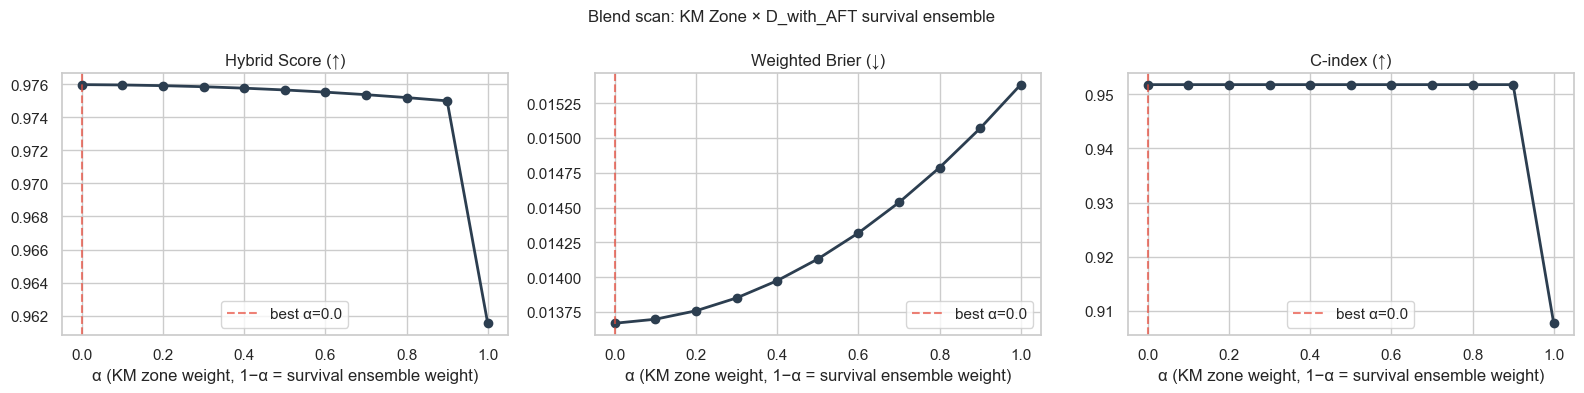

In [11]:
# Plot blend scan results
alphas  = list(blend_results.keys())
hybrids = [blend_results[a]['Hybrid'] for a in alphas]
briers  = [blend_results[a]['W-Brier'] for a in alphas]
cindexs = [blend_results[a]['C-index'] for a in alphas]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, vals, title, arrow in zip(
        axes,
        [hybrids, briers, cindexs],
        ['Hybrid Score (↑)', 'Weighted Brier (↓)', 'C-index (↑)'],
        [True, False, True]):
    ax.plot(alphas, vals, 'o-', color='#2c3e50', lw=2)
    best_val = max(vals) if arrow else min(vals)
    best_a   = alphas[vals.index(best_val)]
    ax.axvline(best_a, color='#e74c3c', ls='--', alpha=0.7,
               label=f'best α={best_a:.1f}')
    ax.set_xlabel('α (KM zone weight, 1−α = survival ensemble weight)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Blend scan: KM Zone × D_with_AFT survival ensemble', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Optional: Platt Calibration

Sigmoid calibration: `calibrated_p = σ(A × logit(p) + B)` fitted per horizon.  
Only **2 parameters per horizon** (8 total). Far lighter than isotonic calibration.  
Trained on OOF predictions from the blend CV above.

Set `USE_PLATT = False` in the config cell to skip this.

In [12]:
def platt_fit(p_oof, y_obs, clip_eps=1e-6):
    """
    Fit Platt scaling: calibrated_p = σ(A * logit(p) + B)
    Returns (A, B) fitted via scipy minimize on log-loss.
    """
    from scipy.optimize import minimize
    p_safe   = np.clip(p_oof, clip_eps, 1 - clip_eps)
    log_odds = logit(p_safe)

    def neg_log_loss(params):
        A, B = params
        p_cal = expit(A * log_odds + B)
        p_cal = np.clip(p_cal, clip_eps, 1 - clip_eps)
        return -np.mean(y_obs * np.log(p_cal) + (1 - y_obs) * np.log(1 - p_cal))

    res = minimize(neg_log_loss, x0=[1.0, 0.0], method='L-BFGS-B')
    return res.x  # (A, B)

def platt_transform(p, A, B, clip_eps=1e-6):
    p_safe   = np.clip(p, clip_eps, 1 - clip_eps)
    log_odds = logit(p_safe)
    return expit(A * log_odds + B)


def cv_blend_platt(X, ye, yt, km_alpha, survival_weights, n_folds=N_CV_FOLDS):
    """
    CV with blend + per-horizon Platt calibration.
    Outer: evaluate on val fold.
    Inner: fit Platt on tr fold's own OOF predictions (one inner fold).
    """
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    rows = []
    for fold, (tr, val) in enumerate(skf.split(X, ye), 1):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        ye_tr, yt_tr = ye[tr], yt[tr]
        ye_val, yt_val = ye[val], yt[val]

        # ----- fit all models on the training fold -----
        km = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
        km.fit(X_tr, ye_tr, yt_tr)

        surv_models = {}
        for name in survival_weights:
            m = build_model(name, TUNED_PARAMS[name])
            m.fit(X_tr, ye_tr, yt_tr)
            surv_models[name] = m

        # ----- get inner-OOF blend probs on tr to fit Platt -----
        inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED + fold)
        oof_blend = {H: np.zeros(len(tr)) for H in HORIZONS}
        for itr, ival in inner_skf.split(X_tr, ye_tr):
            km_i = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
            km_i.fit(X_tr.iloc[itr], ye_tr[itr], yt_tr[itr])
            km_i_probs = km_i.predict_proba(X_tr.iloc[ival])

            mp_i = {}
            for name in survival_weights:
                mi = build_model(name, TUNED_PARAMS[name])
                mi.fit(X_tr.iloc[itr], ye_tr[itr], yt_tr[itr])
                mp_i[name] = mi.predict_survival_probs(X_tr.iloc[ival])
            surv_i = weighted_ensemble(mp_i, survival_weights)
            bl_i   = blend_probs(km_i_probs, surv_i, alpha=km_alpha)
            for H in HORIZONS:
                oof_blend[H][ival] = bl_i[H]

        # ----- fit Platt params on inner OOF -----
        platt_params = {}
        for H in HORIZONS:
            mask  = ~((ye_tr == 0) & (yt_tr < H))
            y_obs = ((ye_tr == 1) & (yt_tr <= H)).astype(float)
            if y_obs[mask].sum() > 2:
                platt_params[H] = platt_fit(oof_blend[H][mask], y_obs[mask])
            else:
                platt_params[H] = np.array([1.0, 0.0])  # identity if too few events

        # ----- final val predictions: blend then Platt -----
        km_val   = km.predict_proba(X_val)
        mp_val   = {n: surv_models[n].predict_survival_probs(X_val) for n in survival_weights}
        surv_val = weighted_ensemble(mp_val, survival_weights)
        bl_val   = blend_probs(km_val, surv_val, alpha=km_alpha)

        cal_val = {}
        for H in HORIZONS:
            A, B = platt_params[H]
            cal_val[H] = platt_transform(bl_val[H], A, B)
        cal_val = enforce_monotonicity(cal_val)

        row = evaluate(ye_val, yt_val, cal_val)
        row['Fold'] = fold
        rows.append(row)

    df   = pd.DataFrame(rows)
    mean = df[['C-index','W-Brier','Hybrid']].mean()
    std  = df[['C-index','W-Brier','Hybrid']].std()
    return mean.to_dict(), std.to_dict(), df


if USE_PLATT:
    print(f'CV: Blend (α={best_alpha}) + Platt calibration...')
    platt_mean, platt_std, platt_fold_df = cv_blend_platt(
        X_all, y_event, y_time, best_alpha, SURVIVAL_WEIGHTS)
    print(f'  Hybrid : {platt_mean["Hybrid"]:.5f} ± {platt_std["Hybrid"]:.5f}')
    print(f'  C-index: {platt_mean["C-index"]:.4f}')
    print(f'  W-Brier: {platt_mean["W-Brier"]:.4f}')
else:
    print('Platt calibration skipped (USE_PLATT=False).')

CV: Blend (α=0.0) + Platt calibration...
  Hybrid : 0.97631 ± 0.01271
  C-index: 0.9518
  W-Brier: 0.0132


## 8. CV Summary

In [13]:
summary_rows = [
    {'Config': 'KM_zone_only',          **km_mean},
    {'Config': 'D_with_AFT_only',        **surv_mean},
    {'Config': f'Blend_alpha={best_alpha}', **blend_results[best_alpha]},
]
if USE_PLATT:
    summary_rows.append({'Config': f'Blend_alpha={best_alpha}+Platt', **platt_mean})

summary_df = pd.DataFrame(summary_rows).set_index('Config')
print('=== CV COMPARISON ===')
print(summary_df[['C-index','W-Brier','Hybrid']].round(5).to_string())
print()
best_config = summary_df['Hybrid'].idxmax()
print(f'Best config: {best_config}  (Hybrid={summary_df.loc[best_config, "Hybrid"]:.5f})')

=== CV COMPARISON ===
                       C-index  W-Brier  Hybrid
Config                                         
KM_zone_only           0.90772  0.01538 0.96155
D_with_AFT_only        0.95178  0.01367 0.97597
Blend_alpha=0.0        0.95178  0.01367 0.97597
Blend_alpha=0.0+Platt  0.95178  0.01318 0.97631

Best config: Blend_alpha=0.0+Platt  (Hybrid=0.97631)


## 9. Generate Submission Files

In [14]:
# ── Fit all models on FULL training set ──
print('Fitting all models on full training set...')

km_full = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
km_full.fit(X_all, y_event, y_time)
km_test_probs = km_full.predict_proba(X_test)
print('KM zone model fitted.')

surv_models_full = {}
surv_test_probs  = {}
for name in SURVIVAL_WEIGHTS:
    m = build_model(name, TUNED_PARAMS[name])
    m.fit(X_all, y_event, y_time)
    surv_models_full[name] = m
    surv_test_probs[name]  = m.predict_survival_probs(X_test)
    print(f'{name}: fitted.')

surv_ensemble_test = weighted_ensemble(surv_test_probs, SURVIVAL_WEIGHTS)

# ── Build submission dict ──
to_submit = {
    'D_with_AFT_only':           surv_ensemble_test,
    'KM_zone_only':              km_test_probs,
    f'blend_alpha_{best_alpha}': blend_probs(km_test_probs, surv_ensemble_test, alpha=best_alpha),
}

print('Predictions generated.')

Fitting all models on full training set...
KM zone model fitted.
GBT: fitted.
RSF: fitted.
CoxPH: fitted.
WeibullAFT: fitted.
Predictions generated.


In [15]:
# ── Optional: fit and apply Platt calibration on OOF then re-apply to test ──
if USE_PLATT:
    print('Fitting Platt calibration on full OOF predictions...')

    # Collect OOF blend predictions for Platt fitting
    skf     = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)
    oof_blend_train = {H: np.zeros(len(y_event)) for H in HORIZONS}

    for tr, val in skf.split(X_all, y_event):
        km_f = KMZoneModel(zone_boundary_m=ZONE_BOUNDARY_M)
        km_f.fit(X_all.iloc[tr], y_event[tr], y_time[tr])
        km_f_probs = km_f.predict_proba(X_all.iloc[val])

        mp_f = {}
        for name in SURVIVAL_WEIGHTS:
            mf = build_model(name, TUNED_PARAMS[name])
            mf.fit(X_all.iloc[tr], y_event[tr], y_time[tr])
            mp_f[name] = mf.predict_survival_probs(X_all.iloc[val])
        surv_f = weighted_ensemble(mp_f, SURVIVAL_WEIGHTS)
        bl_f   = blend_probs(km_f_probs, surv_f, alpha=best_alpha)
        for H in HORIZONS:
            oof_blend_train[H][val] = bl_f[H]

    # Fit Platt params
    final_platt_params = {}
    for H in HORIZONS:
        mask  = ~((y_event == 0) & (y_time < H))
        y_obs = ((y_event == 1) & (y_time <= H)).astype(float)
        if y_obs[mask].sum() > 2:
            final_platt_params[H] = platt_fit(oof_blend_train[H][mask], y_obs[mask])
        else:
            final_platt_params[H] = np.array([1.0, 0.0])
        A, B = final_platt_params[H]
        print(f'  H={H}h: A={A:.3f}, B={B:.3f}')

    # Apply to test blend
    blend_test = to_submit[f'blend_alpha_{best_alpha}']
    cal_test   = {H: platt_transform(blend_test[H], *final_platt_params[H]) for H in HORIZONS}
    cal_test   = enforce_monotonicity(cal_test)
    to_submit[f'blend_alpha_{best_alpha}_platt'] = cal_test
    print('Platt calibration applied to test predictions.')

Fitting Platt calibration on full OOF predictions...
  H=12h: A=1.451, B=-0.482
  H=24h: A=1.386, B=-0.750
  H=48h: A=3.078, B=-4.525
  H=72h: A=3.567, B=0.849
Platt calibration applied to test predictions.


In [16]:
# ── Write CSV files ──
sample = pd.read_csv(DATA_DIR + 'sample_submission.csv')

for name, probs in to_submit.items():
    # Verify monotonicity
    for i in range(len(X_test)):
        p = [probs[H][i] for H in HORIZONS]
        assert p == sorted(p), f'Monotonicity violation at row {i} in {name}'

    sub = pd.DataFrame({
        'event_id': test_raw['event_id'].values,
        'prob_12h': probs[12],
        'prob_24h': probs[24],
        'prob_48h': probs[48],
        'prob_72h': probs[72],
    })
    assert list(sub.columns) == list(sample.columns)
    assert set(sub['event_id']) == set(sample['event_id'])

    fname = f'submission_v6_{name}.csv'
    sub.to_csv(fname, index=False)
    print(f'Saved {fname}')

print('\nAll submission files generated.')

Saved submission_v6_D_with_AFT_only.csv
Saved submission_v6_KM_zone_only.csv
Saved submission_v6_blend_alpha_0.0.csv
Saved submission_v6_blend_alpha_0.0_platt.csv

All submission files generated.


In [17]:
# ── Inspect KM zone model test predictions ──
close_test = X_test['dist_min_ci_0_5h'] < ZONE_BOUNDARY_M
print(f'Test set distance zones (boundary={ZONE_BOUNDARY_M}m):')
print(f'  Close: {close_test.sum()} fires')
print(f'  Far:   {(~close_test).sum()} fires')
print()

# Show prediction distribution by zone for the best blend
best_preds = to_submit[f'blend_alpha_{best_alpha}']
for zone_label, mask in [('Close', close_test.values), ('Far', ~close_test.values)]:
    print(f'  {zone_label} fires — best blend predictions:')
    for H in HORIZONS:
        vals = best_preds[H][mask]
        print(f'    prob_{H}h: mean={vals.mean():.3f}, '
              f'min={vals.min():.3f}, max={vals.max():.3f}')

Test set distance zones (boundary=5000m):
  Close: 28 fires
  Far:   67 fires

  Close fires — best blend predictions:
    prob_12h: mean=0.638, min=0.408, max=0.970
    prob_24h: mean=0.874, min=0.735, max=0.987
    prob_48h: mean=0.932, min=0.836, max=0.995
    prob_72h: mean=0.991, min=0.954, max=0.998
  Far fires — best blend predictions:
    prob_12h: mean=0.008, min=0.002, max=0.046
    prob_24h: mean=0.017, min=0.006, max=0.085
    prob_48h: mean=0.023, min=0.009, max=0.117
    prob_72h: mean=0.046, min=0.021, max=0.205


## 10. Summary

In [18]:
print('=' * 70)
print('  NOTEBOOK 06 SUMMARY')
print('=' * 70)
print(f'  Zone boundary: {ZONE_BOUNDARY_M}m  |  Platt calibration: {USE_PLATT}')
print()
print('  CV Results:')
for idx, row in summary_df[['C-index','W-Brier','Hybrid']].iterrows():
    marker = ' ← best CV' if idx == best_config else ''
    print(f'    {idx:<36} Hybrid={row["Hybrid"]:.5f}{marker}')
print()
print('  Submission files generated:')
for name in to_submit:
    print(f'    submission_v6_{name}.csv')
print()
print('  Recommended upload order (try KM_zone_only first as a sanity check):')
print('  1. submission_v6_KM_zone_only.csv')
print(f'  2. submission_v6_blend_alpha_{best_alpha}.csv')
if USE_PLATT:
    print(f'  3. submission_v6_blend_alpha_{best_alpha}_platt.csv')
print('=' * 70)

  NOTEBOOK 06 SUMMARY
  Zone boundary: 5000m  |  Platt calibration: True

  CV Results:
    KM_zone_only                         Hybrid=0.96155
    D_with_AFT_only                      Hybrid=0.97597
    Blend_alpha=0.0                      Hybrid=0.97597
    Blend_alpha=0.0+Platt                Hybrid=0.97631 ← best CV

  Submission files generated:
    submission_v6_D_with_AFT_only.csv
    submission_v6_KM_zone_only.csv
    submission_v6_blend_alpha_0.0.csv
    submission_v6_blend_alpha_0.0_platt.csv

  Recommended upload order (try KM_zone_only first as a sanity check):
  1. submission_v6_KM_zone_only.csv
  2. submission_v6_blend_alpha_0.0.csv
  3. submission_v6_blend_alpha_0.0_platt.csv
